## Measures - Experiments

In [42]:
import pandas as pd
import pm4py
import pickle
import os
import numpy as np

from Soccer_OCEL.idsse_import import get_games

from pm4py.objects.ocel.importer.xmlocel import importer as xmlocel_importer
from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [78]:
path='data/28196177'
games=get_games(path)#load all 7 games
#games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
GDs=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
    GDs.append(GD_loaded)
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

In [7]:
print('Total: ', len(allgame_df), ' events')
for Game, df in zip(games, all_games):
    print('Game ', Game, ': ', len(df), ' events')

Total:  30023  events
Game  J03WMX :  4609  events
Game  J03WN1 :  3733  events
Game  J03WQQ :  4574  events
Game  J03WR9 :  4048  events
Game  J03WPY :  4501  events
Game  J03WOH :  4152  events
Game  J03WOY :  4406  events


In [80]:
print('Total: ', len(np.unique(allgame_df['case:concept:name'])), ' possessions/instances')
for Game, df in zip(games, all_games):
    print('Game ', Game, ': ', len(np.unique(df['case:concept:name'])), ' possessions')

Total:  2559  possessions/instances
Game  J03WMX :  438  possessions
Game  J03WN1 :  423  possessions
Game  J03WQQ :  337  possessions
Game  J03WR9 :  302  possessions
Game  J03WPY :  340  possessions
Game  J03WOH :  331  possessions
Game  J03WOY :  388  possessions


In [57]:
event_log = pm4py.convert_to_event_log(allgame_df)
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=['case:concept:name',"Forward", "Midfielder", "Defender", "Goalkeeper"]#['Team','Player','Session', 'case:concept:name']
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])

In [13]:
_,starts,ends=pm4py.discovery.discover_dfg(event_log)

In [14]:
starts

{'KickOff_Play_Pass': 7,
 'Foul': 22,
 'ShotAtGoal': 55,
 'OtherBallAction': 447,
 'Play_Pass': 582,
 'TacklingGame': 239,
 'Lateral Repositioning': 198,
 'Wing Retreat': 32,
 'Holding Wing Defensive First': 35,
 'Holding Wing Midfield': 110,
 'Central Transition': 106,
 'Holding Central Midfield': 106,
 'Wing Transition': 107,
 'Holding Central Defensive First': 76,
 'BallClaiming': 55,
 'Central Retreat': 38,
 'Pass_Intercepted': 8,
 'Securing Central Attack Third': 54,
 'Play_Cross': 16,
 'Wing Advance': 43,
 'PenaltyNotAwarded': 7,
 'Diagonal Repositioning': 50,
 'Central Advance': 39,
 'Offside': 7,
 'FreeKick_Play_Pass': 6,
 'GoalKick_Play_Pass': 7,
 'ThrowIn_Play_Pass': 44,
 'Pass_Received': 9,
 'Securing Wing Attack Third': 31,
 'ShotWide': 3,
 'PlayerNotSentOff': 3,
 'Nutmeg': 2,
 'SpectacularPlay': 1,
 'OutSubstitution': 2,
 'FinalWhistle': 3,
 'ThrowIn': 2,
 'ChanceWithoutShot': 1,
 'FreeKick_ShotAtGoal': 1,
 'BallDeflection': 1,
 'Caution': 1,
 'CornerKick_Play_Cross': 1,
 

In [58]:
ocel_extended_table = ocel.get_extended_table()
#ocel_extended_table = ocel_extended_table.sort_values("ocel:timestamp")
#ocel_extended_table_game2 = ocel_game2.get_extended_table()

#ocel_extended_table_game2 = ocel_game2.get_extended_table()

ocel_extended_table

,ocel:eid,ocel:activity,ocel:timestamp,attribute:enabled,attribute:x,attribute:y,attribute:session,attribute:team,ocel:type:case:concept:name,ocel:type:Forward,ocel:type:Defender,ocel:type:Midfielder,ocel:type:Goalkeeper
0,0,KickOff_Play_Pass,2022-08-26 16:32:08.110000+00:00,"[Play_Pass_DMR, Play_Pass_ORM, Play_Pass_DML, ...",52.94,34.10,1,Away,[J03WOH_Away_0],[DFL-OBJ-002GAB],NaN,NaN,NaN
1,1,Central Advance,2022-08-26 16:32:08.150000+00:00,[],32.44,45.81,1,Away,[J03WOH_Away_0],NaN,[DFL-OBJ-002GEE],NaN,NaN
2,2,Wing Advance,2022-08-26 16:32:08.150000+00:00,[],52.92,59.16,1,Away,[J03WOH_Away_0],NaN,NaN,[DFL-OBJ-002G2Y],NaN
3,3,Central Transition,2022-08-26 16:32:08.150000+00:00,[],36.92,19.13,1,Away,[J03WOH_Away_0],NaN,[DFL-OBJ-0028SW],NaN,NaN
4,4,Holding Central Midfield,2022-08-26 16:32:08.150000+00:00,[],52.94,34.10,1,Away,[J03WOH_Away_0],[DFL-OBJ-002GAB],NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13127,13127,Holding Wing Midfield,2022-11-05 13:52:17.988000+00:00,[],64.62,11.86,2,Home,[J03WQQ_Home_181],[DFL-OBJ-J01L1F],NaN,NaN,NaN
13128,13128,FreeKick_Play_Pass,2022-11-05 13:52:20.301000+00:00,"[Play_Pass_IVL, Play_Pass_DMR]",24.57,29.28,2,Home,[J03WQQ_Home_181],NaN,NaN,NaN,[DFL-OBJ-0028FW]
13129,13129,Pass_Received,2022-11-05 13:52:20.341000+00:00,[Play_Pass_RM],67.68,11.27,2,Home,[J03WQQ_Home_181],[DFL-OBJ-J01L1F],NaN,NaN,NaN
13130,13130,OtherBallAction,2022-11-05 13:52:26.028000+00:00,[],81.91,15.45,2,Home,[J03WQQ_Home_181],[DFL-OBJ-J01L1F],NaN,NaN,NaN


In [22]:
print("unique activities in game1:", ocel_extended_table['ocel:activity'].unique())

print("Columns in possessionWithShot:", ocel_extended_table.columns.tolist())

unique activities in game1: ['KickOff_Play_Pass' 'Central Advance' 'Wing Advance' 'Central Transition'
 'Holding Central Midfield' 'Wing Transition'
 'Holding Central Defensive First' 'Holding Wing Midfield'
 'Diagonal Repositioning' 'Pass_Received' 'Central Retreat' 'Wing Retreat'
 'Play_Pass' 'Holding Wing Defensive First' 'TacklingGame'
 'OtherBallAction' 'Foul' 'Securing Wing Attack Third' 'Caution'
 'Securing Central Attack Third' 'FreeKick_Play_Cross' 'Cross_Received'
 'ShotAtGoal' 'SavedShot' 'Lateral Repositioning' 'CornerKick_Play_Cross'
 'BlockedShot' 'GoalKick_Play_Pass' 'Pass_Intercepted' 'ThrowIn_Play_Pass'
 'BallClaiming' 'FreeKick_Play_Pass' 'ShotWide' 'Play_Cross'
 'PenaltyNotAwarded' 'VideoAssistantAction' 'Run' 'RefereeBall'
 'Cross_Intercepted' 'ChanceWithoutShot' 'Nutmeg' 'OtherShot'
 'FinalWhistle' 'Offside' 'PossessionLossBeforeGoal' 'Scored'
 'SitterPrevented' 'Penalty_ShotAtGoal' 'OutSubstitution'
 'OtherPlayerAction' 'SpectacularPlay' 'ThrowIn_Play_Cross'
 'Pla

In [ ]:
# turn fields into single string values instead of a list of a string value
ocel_extended_table["ocel:type:case:concept:name"] = ocel_extended_table["ocel:type:case:concept:name"].apply(lambda x: x[0] if isinstance(x, list) else x)
ocel_extended_table["attribute:team"] = ocel_extended_table["attribute:team"].apply(lambda x: x[0] if isinstance(x, list) else x)

#ocel_extended_table_game2["ocel:type:case:concept:name"] = ocel_extended_table_game2["ocel:type:case:concept:name"].apply(lambda x: x[0] if isinstance(x, list) else x)
#ocel_extended_table_game2["attribute:team"] = ocel_extended_table_game2["attribute:team"].apply(lambda x: x[0] if isinstance(x, list) else x)


# separate the rows for away and home teams possessions (but including both teams events during that time)
rows_possessions_away = ocel_extended_table[ocel_extended_table["attribute:team"].str.startswith("Away")]
rows_possessions_home = ocel_extended_table[ocel_extended_table["attribute:team"].str.startswith("Home")]

# group by possessions
possessions_away = rows_possessions_away.groupby("ocel:type:case:concept:name")
possessions_home = rows_possessions_home.groupby("ocel:type:case:concept:name")


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

def basic_count_analysis(away_counts, home_counts):
    # Convert to DataFrame and add a label column
    away_df = pd.DataFrame({'event_count': away_counts, 'team': 'Away'})
    home_df = pd.DataFrame({'event_count': home_counts, 'team': 'Home'})

    # Combine into one DataFrame
    combined_df = pd.concat([away_df, home_df]).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_df, x='event_count', hue='team', kde=True, element='step', stat='density', common_norm=False)
    plt.title("Distribution of Event Counts per Possession (Home vs Away)")
    plt.xlabel("Number of Events in Possession")
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=combined_df, x='team', y='event_count')
    plt.title("Event Count Distribution per Possession")
    plt.ylabel("Number of Events")
    plt.xlabel("Team")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Perform Mann–Whitney U test (two-sided)
    stat, p_value = mannwhitneyu(away_counts, home_counts, alternative='two-sided')

    # Show result
    print(f"Mann–Whitney U test statistic: {stat}")
    print(f"P-value: {p_value:.4f}")


## Total no. of events during possessions

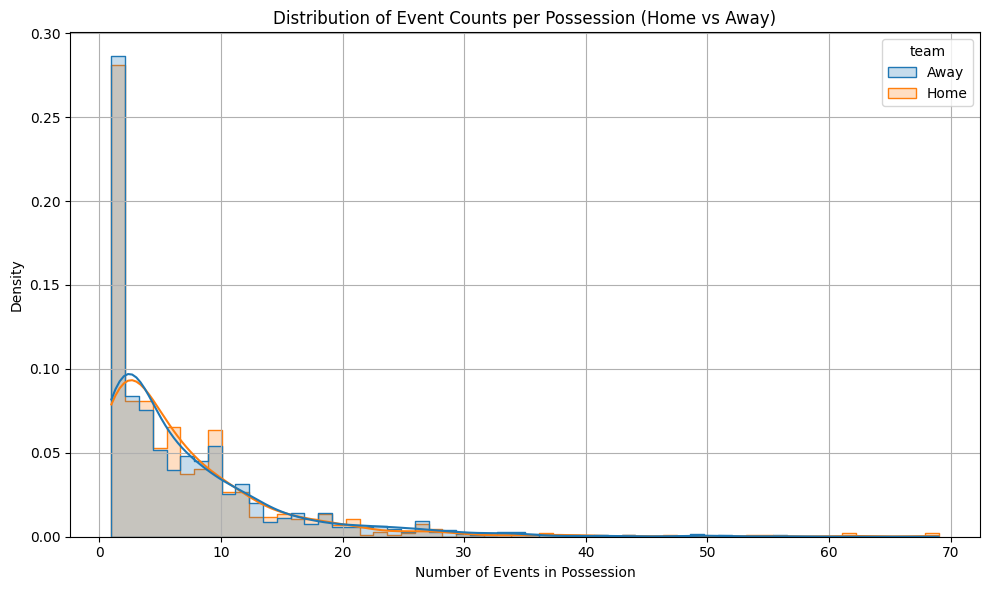

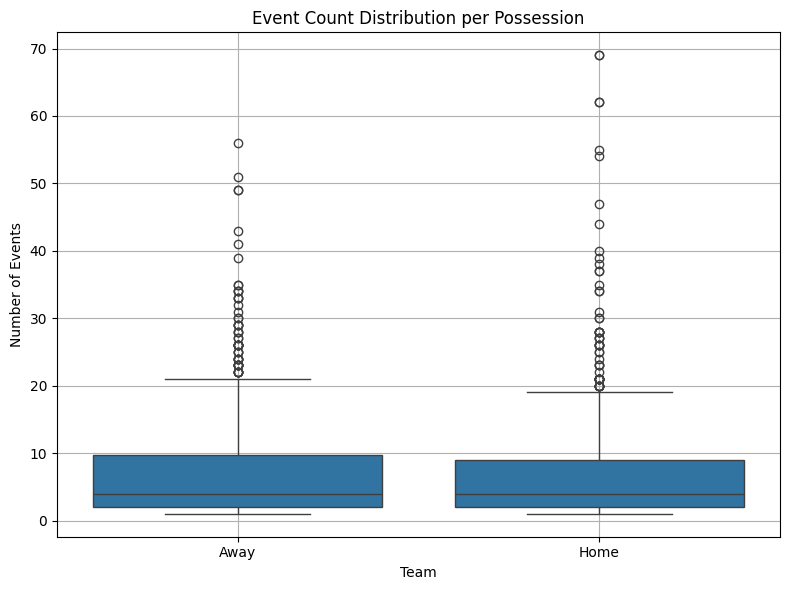

Mann–Whitney U test statistic: 434104.0
P-value: 0.6080


In [61]:
# Count the number of events in each possession
# this includes all the events of both teams during the possession (so also how the other team moves)
away_counts = possessions_away.size()
home_counts = possessions_home.size()
basic_count_analysis(away_counts, home_counts)

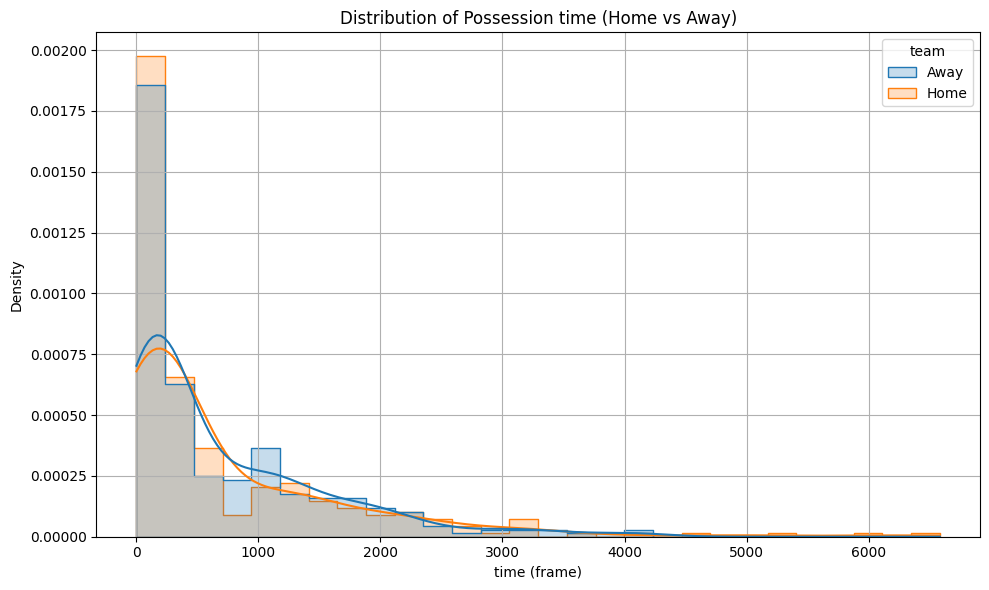

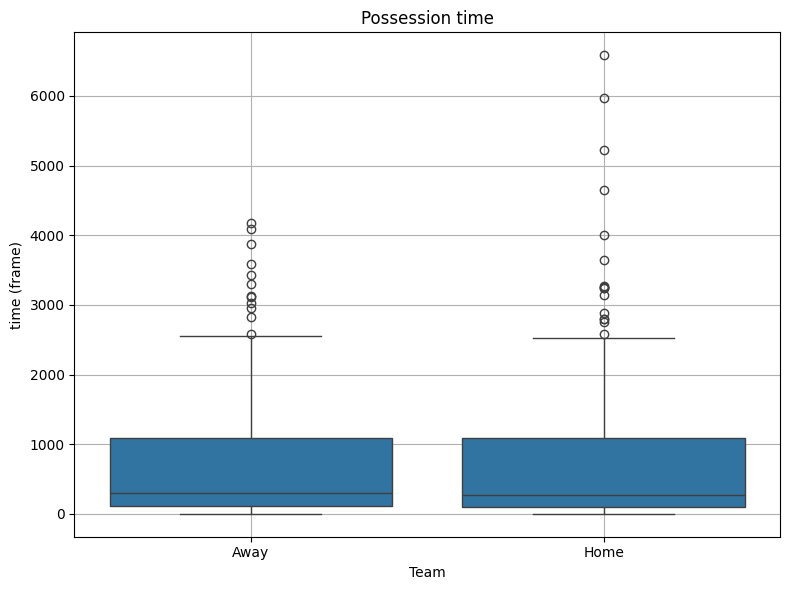

Mann–Whitney U test statistic: 44263.0
P-value: 0.3433


In [62]:
def possession_length_analysis(away_counts, home_counts):
    # Convert to DataFrame and add a label column
    away_df = pd.DataFrame({'event_count': away_counts, 'team': 'Away'})
    home_df = pd.DataFrame({'event_count': home_counts, 'team': 'Home'})

    # Combine into one DataFrame
    combined_df = pd.concat([away_df, home_df]).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_df, x='event_count', hue='team', kde=True, element='step', stat='density', common_norm=False)
    plt.title("Distribution of Possession time (Home vs Away)")
    plt.xlabel("time (frame)")
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=combined_df, x='team', y='event_count')
    plt.title("Possession time")
    plt.ylabel("time (frame)")
    plt.xlabel("Team")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Perform Mann–Whitney U test (two-sided)
    stat, p_value = mannwhitneyu(away_counts, home_counts, alternative='two-sided')

    # Show result
    print(f"Mann–Whitney U test statistic: {stat}")
    print(f"P-value: {p_value:.4f}")
home_f=[]
away_f=[]
for GD in GDs:
    poss=list(GD.possession['firstHalf'].code)+list(GD.possession['firstHalf'].code)
    home_f+=list(np.unique([p for p in poss if p[:4]=='Home'], return_counts=True)[1])
    away_f+=list(np.unique([p for p in poss if p[:4]=='Away'], return_counts=True)[1])
possession_length_analysis(away_f, home_f)

## No. of events of the possessions team during possessions

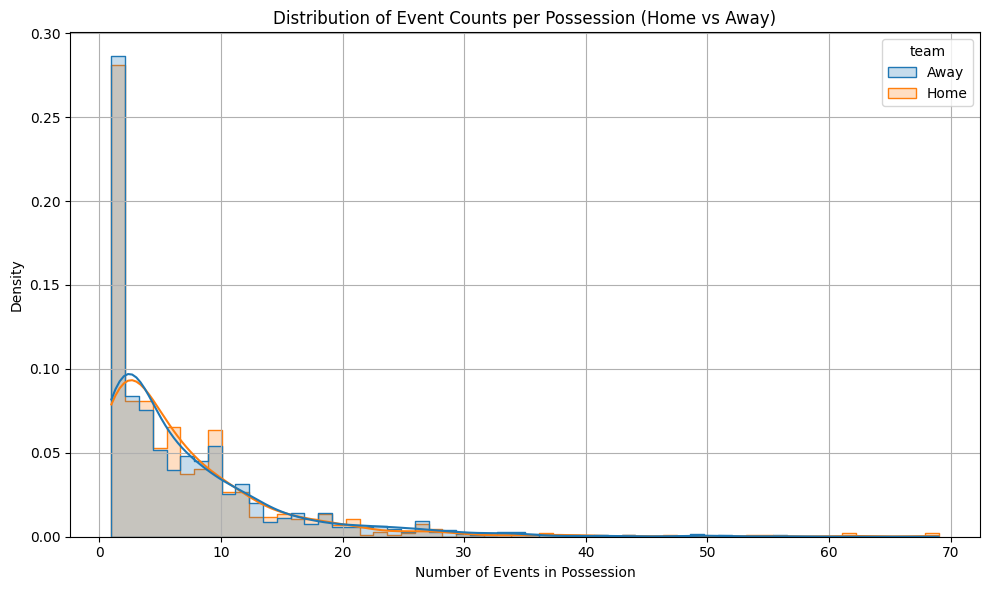

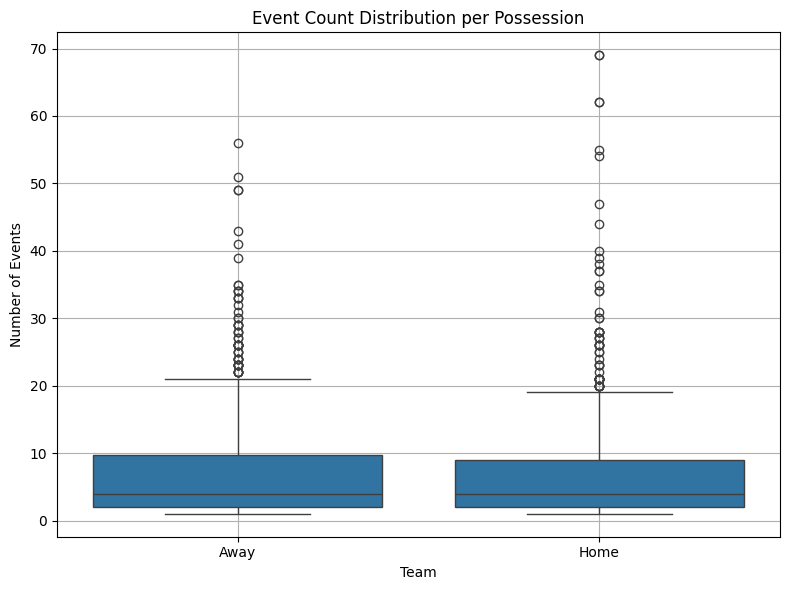

Mann–Whitney U test statistic: 434104.0
P-value: 0.6080


In [63]:
# separate the rows for away and home teams possessions and only their own events
rows_possessions_away_team_away = rows_possessions_away[rows_possessions_away["attribute:team"] == "Away"]
rows_possessions_home_team_home = rows_possessions_home[rows_possessions_home["attribute:team"] == "Home"]

# group by possessions
possessions_away_team_away = rows_possessions_away_team_away.groupby("ocel:type:case:concept:name")
possessions_home_team_home = rows_possessions_home_team_home.groupby("ocel:type:case:concept:name")

# Count the number of events in each possession that belongs to the team that has the possession
away_counts = possessions_away_team_away.size()
home_counts = possessions_home_team_home.size()
basic_count_analysis(away_counts, home_counts)

## How many events for traces with shot?

### Total no. of events during shot possessions

No. of possessions with shot AWAY:  36
No. of possessions with shot HOME:  37


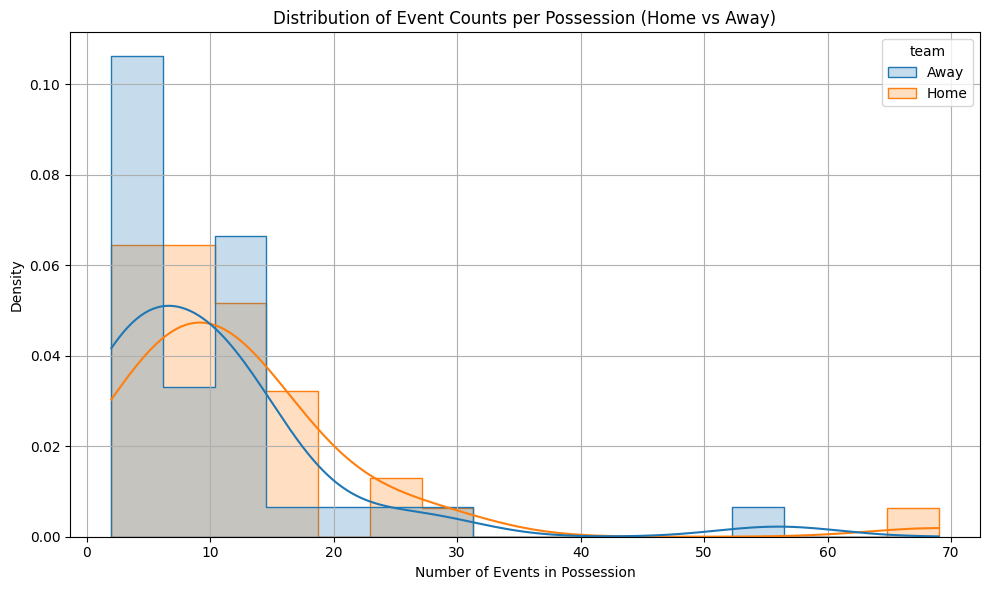

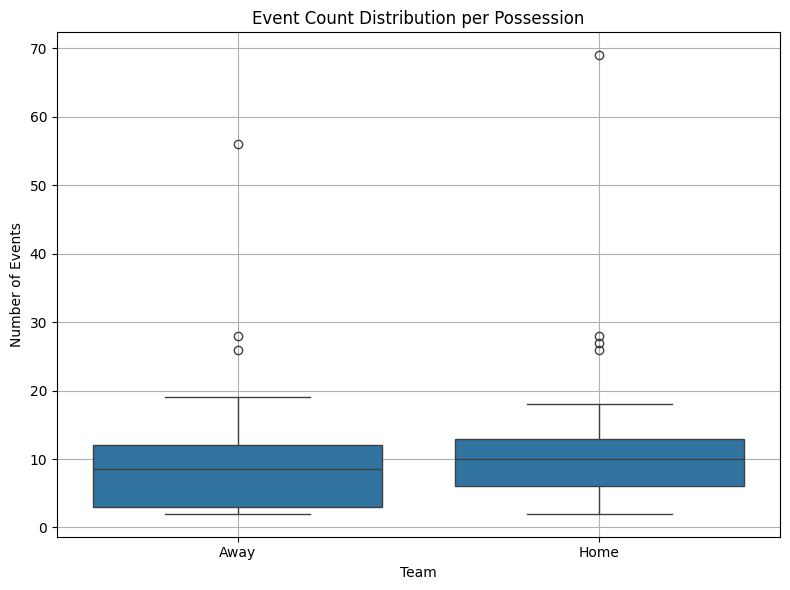

Mann–Whitney U test statistic: 539.0
P-value: 0.1615


In [68]:
# filter for those possessions that have a shot activity
possessions_away_with_shot = possessions_away.filter(lambda x: any(str(act).startswith("Shot") for act in x['ocel:activity'].values))
possessions_away_with_shot = possessions_away_with_shot.groupby("ocel:type:case:concept:name")
print("No. of possessions with shot AWAY: ", possessions_away_with_shot.ngroups)

possessions_home_with_shot = possessions_home.filter(lambda x: any(str(act).startswith("Shot") for act in x['ocel:activity'].values))
possessions_home_with_shot = possessions_home_with_shot.groupby("ocel:type:case:concept:name")
print("No. of possessions with shot HOME: ", possessions_home_with_shot.ngroups)

# This includes all the events of both teams during the possession (so also how the other team moves)
away_counts = possessions_away_with_shot.size()
home_counts = possessions_home_with_shot.size()
basic_count_analysis(away_counts, home_counts)


### Shot teams no. of events during possessions

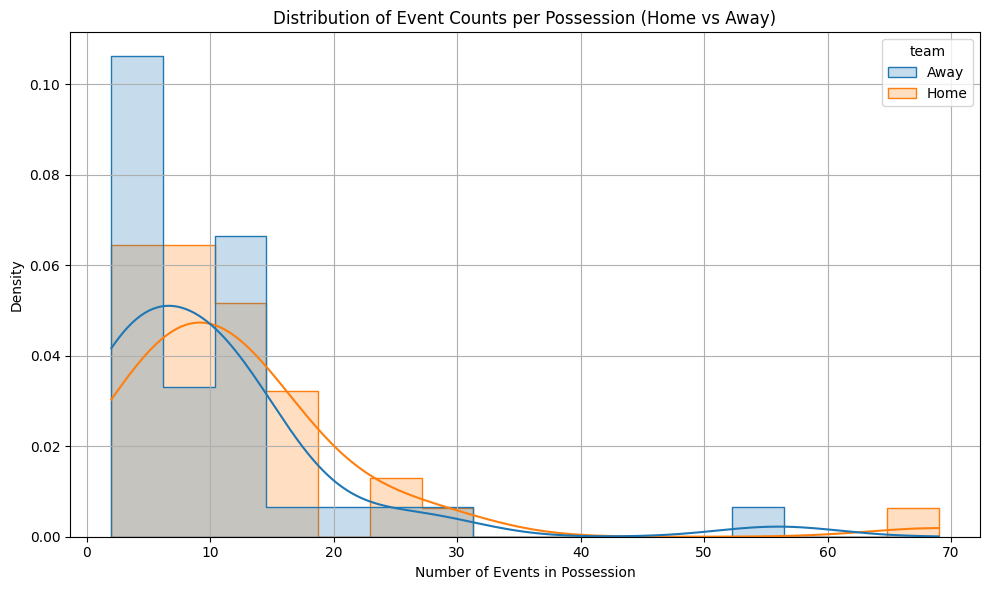

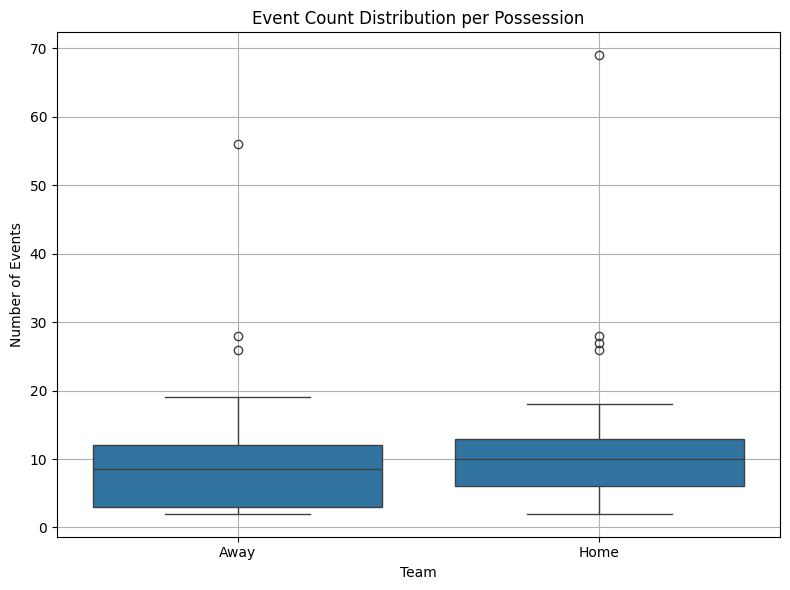

Mann–Whitney U test statistic: 539.0
P-value: 0.1615


In [67]:
# This includes only the events of the team that has the possession
# filter for those possessions that have a shot activity
possessions_away_team_away_with_shot = possessions_away_team_away.filter(lambda x: any(str(act).startswith("Shot") for act in x['ocel:activity'].values))
possessions_away_team_away_with_shot = possessions_away_team_away_with_shot.groupby("ocel:type:case:concept:name")

possessions_home_team_home_with_shot = possessions_home_team_home.filter(lambda x: any(str(act).startswith("Shot") for act in x['ocel:activity'].values))
possessions_home_team_home_with_shot = possessions_home_team_home_with_shot.groupby("ocel:type:case:concept:name")

# This includes only the events of the team that has the possession
away_counts = possessions_away_team_away_with_shot.size()
home_counts = possessions_home_team_home_with_shot.size()
basic_count_analysis(away_counts, home_counts)

In [74]:
away_possessions_with_shot_groupIDs = list(possessions_away_team_away_with_shot.groups.keys())
print("Available possession group names (Away team, with shot):")
print(away_possessions_with_shot_groupIDs)

Available possession group names (Away team, with shot):
['J03WOH_Away_125', 'J03WOH_Away_134', 'J03WOH_Away_145', 'J03WOH_Home_1', 'J03WOH_Home_13', 'J03WOH_Home_169', 'J03WOH_Home_3', 'J03WOH_Home_47', 'J03WOH_Home_70', 'J03WOH_Home_82', 'J03WOH_Home_87', 'J03WOH_Home_94', 'J03WOY_Away_121', 'J03WOY_Away_15', 'J03WOY_Away_166', 'J03WOY_Away_177', 'J03WOY_Away_184', 'J03WOY_Home_136', 'J03WOY_Home_15', 'J03WOY_Home_198', 'J03WOY_Home_91', 'J03WOY_Home_92', 'J03WQQ_Away_103', 'J03WQQ_Away_165', 'J03WQQ_Away_169', 'J03WQQ_Away_30', 'J03WQQ_Away_46', 'J03WQQ_Away_71', 'J03WQQ_Away_85', 'J03WQQ_Away_91', 'J03WQQ_Home_115', 'J03WQQ_Home_134', 'J03WQQ_Home_171', 'J03WQQ_Home_27', 'J03WQQ_Home_30', 'J03WQQ_Home_85']


In [75]:
groupId = away_possessions_with_shot_groupIDs[0]

possessionWithShot = possessions_away_team_away_with_shot.get_group(groupId)
possessionWithShot_events = possessionWithShot[possessionWithShot['ocel:activity'] != "Player changes position"]['ocel:activity'].values
print("Events in possession (Away Team) excluding 'Player changes position':")
for event in possessionWithShot_events:
    print(event)

Events in possession (Away Team) excluding 'Player changes position':
Play_Pass
Pass_Received
Play_Pass
Pass_Received
OtherBallAction
TacklingGame
FreeKick_Play_Pass
Pass_Received
Play_Pass
Pass_Received
TacklingGame
Play_Pass
Pass_Received
Play_Pass
Pass_Received
Play_Pass
Pass_Received
ShotAtGoal
ShotWide


In [72]:
def get_change_position_count_of_shot_player(groupId, possessions):
    shot_event_possession = possessions.get_group(groupId)
    shot_event = shot_event_possession[shot_event_possession['ocel:activity'].apply(lambda act: str(act).startswith('SHOT'))]
    # Get the player who performed the shot
    player = shot_event["ocel:type:Player"].values[0]
    #print("Player who performed the shot:", player)
    # Get all activities in group performed by the player who took the shot
    player_id = player[0]
    group = possessions.get_group(groupId)
    player_activities = group[group["ocel:type:Player"].apply(lambda x: player_id in x)]["ocel:activity"].values
    change_position_count = (player_activities == "Player changes position").sum()
    #print(f"Number of 'Player changes position' activities for {player_id}: {change_position_count}")
    return change_position_count
    #print(f"All activities in group by {player_id}:")
    #for act in player_activities:
    #    print(act)

In [70]:
home_possessions_with_shot_groupIDs = list(possessions_home_team_home_with_shot.groups.keys())
print("Available possession group names (Home team, with shot):")
print(home_possessions_with_shot_groupIDs)

#possessionWithShot = possessions_home_team_home_with_shot.get_group("HA4")
#possessionWithShot_events = possessionWithShot[possessionWithShot['ocel:activity'] != "Player changes position"]['ocel:activity'].values
#print("Events in possession (Home Team) excluding 'Player changes position':")
#for event in possessionWithShot_events:
#    print(event)

Available possession group names (Home team, with shot):
['J03WOH_Away_16', 'J03WOH_Away_61', 'J03WOH_Away_69', 'J03WOH_Away_78', 'J03WOH_Home_103', 'J03WOH_Home_141', 'J03WOH_Home_152', 'J03WOH_Home_166', 'J03WOH_Home_175', 'J03WOH_Home_20', 'J03WOH_Home_37', 'J03WOH_Home_62', 'J03WOH_Home_75', 'J03WOH_Home_97', 'J03WOY_Away_124', 'J03WOY_Away_141', 'J03WOY_Away_172', 'J03WOY_Away_19', 'J03WOY_Away_197', 'J03WOY_Away_32', 'J03WOY_Away_54', 'J03WOY_Away_61', 'J03WOY_Home_102', 'J03WOY_Home_139', 'J03WOY_Home_148', 'J03WOY_Home_181', 'J03WQQ_Away_121', 'J03WQQ_Away_134', 'J03WQQ_Away_42', 'J03WQQ_Home_102', 'J03WQQ_Home_119', 'J03WQQ_Home_120', 'J03WQQ_Home_22', 'J03WQQ_Home_30', 'J03WQQ_Home_36', 'J03WQQ_Home_79', 'J03WQQ_Home_9']


## Shot players no. of position changes

In [76]:
away_shot_player_activity_counts = [get_change_position_count_of_shot_player(gid, possessions_away_team_away_with_shot) for gid in away_possessions_with_shot_groupIDs]
print("Away team shot player 'Player changes position' activity counts:")
print(away_shot_player_activity_counts)

home_shot_player_activity_counts = [get_change_position_count_of_shot_player(gid, possessions_home_team_home_with_shot) for gid in home_possessions_with_shot_groupIDs]
print("Home team shot player 'Player changes position' activity counts:")
print(home_shot_player_activity_counts)

basic_count_analysis(away_shot_player_activity_counts, home_shot_player_activity_counts)

KeyError: 'ocel:type:Player'

/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/pm4py/objects/ocel/util/extended_table.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_df[internal_index] = events_df.index
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/pm4py/objects/ocel/util/extended_table.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_df.sort_values([event_timestamp, internal_index], inplace=True)
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update ju

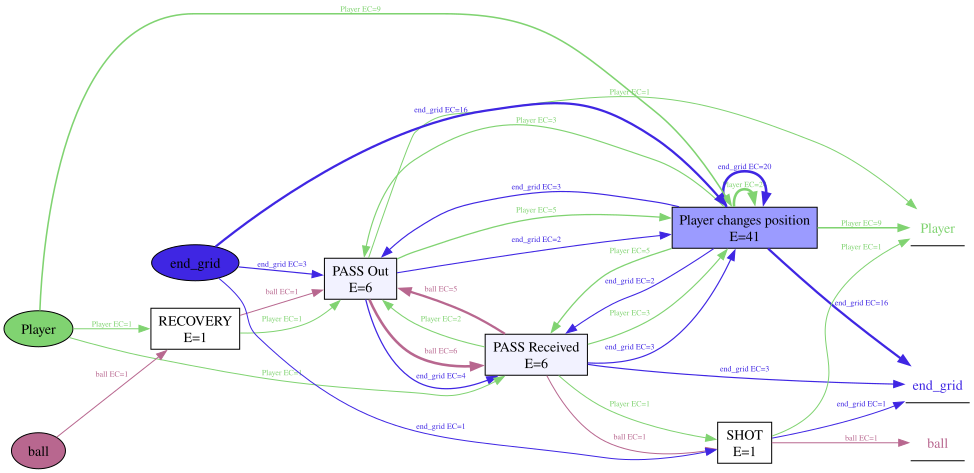

In [16]:
from pm4py.objects.ocel.importer.csv import importer as csv_importer

#['AA103', 'AA138', 'AA156', 'AA16', 'AA166', 'AA36']

groupId = "AA156"

possessions_away_team_away_with_shot.get_group(groupId).to_csv("possessions_away_team_away_with_shot.csv", index=False)

ocel_filtered = csv_importer.apply("possessions_away_team_away_with_shot.csv")

#pm4py.write_ocel(ocel_filtered, "output_logs/possessions_away_team_away_with_shot.xmlocel")

dfg=pm4py.ocel.discover_ocdfg(ocel_filtered)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

In [20]:
####################################
# GET BALL MOVEMENT DURING THE POSSESSION
ball_rows = possessions_away_team_away_with_shot.get_group(groupId)[possessions_away_team_away_with_shot.get_group(groupId)["ocel:activity"] != "Player changes position"]
# extract the balls movement during the possession
ball_movement = ball_rows["attribute:start_grid"]
# Convert string representation of list to actual list and extract the value
print("ball movement:", ball_movement)
ball_movement_grid_cells = ball_movement.tolist()
ball_movement_activities = ball_rows["ocel:activity"].tolist()

# Filter out "PASS Received" activities and their corresponding grid cells
#mask = ball_rows["ocel:activity"] != "PASS Received"
#ball_movement_grid_cells = ball_movement[mask].tolist()
#ball_movement_activities = ball_rows["ocel:activity"][mask].tolist()

print("ball movement:", ball_movement_grid_cells)
print("ball movement activities:", ball_movement_activities)
# Enumerate the ball movement activities
# Replace "PASS Out" with "PASS" in ball_movement_activities
#ball_movement_activities = [act.replace("PASS Out", "PASS") for act in ball_movement_activities]
ball_movement_activities = [f"{i+1}. {act}" for i, act in enumerate(ball_movement_activities)]
print("ball movement activities enumerated:", ball_movement_activities)

####################################
# GET PLAYER MOVEMENTS DURING THE POSSESSION
player_rows = possessions_away_team_away_with_shot.get_group(groupId)[possessions_away_team_away_with_shot.get_group(groupId)["ocel:activity"] == "Player changes position"]
# Group player_rows by player (note: player is a list like [Player17], so use the first element)
player_groups = player_rows.groupby(player_rows["ocel:type:Player"].apply(lambda x: x[0] if isinstance(x, list) else x))
for player_id, group in player_groups:
    print(f"Player: {player_id}")
    # Unpack end_grid values from lists like [D5] to D5
    unpacked_end_grids = group["ocel:type:end_grid"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
    print(unpacked_end_grids)
    print("-" * 40)

player_end_grid_dict = {
    player_id: group["ocel:type:end_grid"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x).tolist()
    for player_id, group in player_groups
}
print(player_end_grid_dict)

ball movement: 15896    B3
15897    B3
15901    B4
15913    B4
15915    B3
15921    B3
15930    D1
15943    D1
15945    D1
15949    D1
15962    E1
15988    F2
15991    F2
15992    F2
Name: attribute:start_grid, dtype: object
ball movement: ['B3', 'B3', 'B4', 'B4', 'B3', 'B3', 'D1', 'D1', 'D1', 'D1', 'E1', 'F2', 'F2', 'F2']
ball movement activities: ['RECOVERY', 'PASS Out', 'PASS Received', 'PASS Out', 'PASS Received', 'PASS Out', 'PASS Received', 'PASS Out', 'PASS Received', 'PASS Out', 'PASS Received', 'PASS Out', 'PASS Received', 'SHOT']
ball movement activities enumerated: ['1. RECOVERY', '2. PASS Out', '3. PASS Received', '4. PASS Out', '5. PASS Received', '6. PASS Out', '7. PASS Received', '8. PASS Out', '9. PASS Received', '10. PASS Out', '11. PASS Received', '12. PASS Out', '13. PASS Received', '14. SHOT']
Player: Player15
15947    C3
15982    D3
Name: ocel:type:end_grid, dtype: object
----------------------------------------
Player: Player16
15905    B3
15924    B2
15942    C2


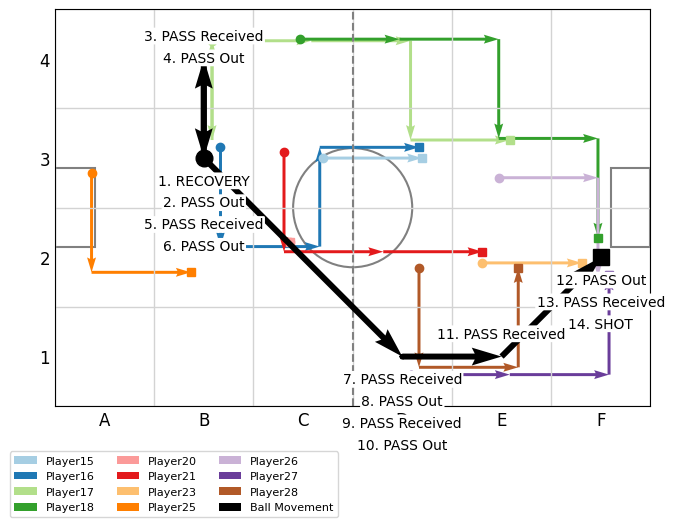

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import string
import matplotlib.cm as cm

# Convert grid cell name to center coordinates (A1 is bottom-left)
def cell_to_coords(cell):
    col_letter = cell[0].upper()
    row_number = int(cell[1:]) - 1
    col_number = string.ascii_uppercase.index(col_letter)
    return (col_number + 0.5, row_number + 0.5)


colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a','#b15928']

fig, ax = plt.subplots(figsize=(7, 7))

cols = 6  # A-F
rows = 4  # 1-4

# Draw grid lines
for i in range(cols + 1):
    ax.plot([i, i], [0, rows], color='lightgray', linewidth=1)
for j in range(rows + 1):
    ax.plot([0, cols], [j, j], color='lightgray', linewidth=1)

# Set axis limits
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)

# Set axis ticks to be at cell edges (so labels appear centered on cells)
ax.set_xticks(np.arange(cols) + 0.5)
ax.set_yticks(np.arange(rows) + 0.5)

# Set tick labels: x-axis letters A-F
ax.set_xticklabels(list(string.ascii_uppercase[:cols]), fontsize=12)
# y-axis numbers 1-4 (bottom to top)
ax.set_yticklabels([str(i) for i in range(1, rows + 1)], fontsize=12)

# Remove minor ticks and grid
ax.tick_params(axis='both', which='both', length=0)  # no tick marks

# Draw soccer field elements (unchanged)
ax.plot([3, 3], [0, rows], color='gray', linestyle='--', linewidth=1.5)
center_circle = plt.Circle((3, 2), 0.6, color='gray', fill=False, linewidth=1.5)
ax.add_patch(center_circle)
left_goal_area = plt.Rectangle((0, 1.6), 0.4, 0.8, edgecolor='gray', facecolor='none', linewidth=1.5)
ax.add_patch(left_goal_area)
right_goal_area = plt.Rectangle((5.6, 1.6), 0.4, 0.8, edgecolor='gray', facecolor='none', linewidth=1.5)
ax.add_patch(right_goal_area)

# Draw paths with slight offsets (unchanged)
offset_magnitude = 0.2
angle_step = 2 * np.pi / len(player_end_grid_dict.items())

# Example: player_paths = {'Player17': ['B3', 'B4', 'C4', ...], ...}
for i, (player, path) in enumerate(player_end_grid_dict.items()):
    coords = [cell_to_coords(cell) for cell in path]
    angle = i * angle_step
    dx = offset_magnitude * np.cos(angle)
    dy = offset_magnitude * np.sin(angle)
    coords = [(x + dx, y + dy) for (x, y) in coords]
    X, Y = zip(*coords)
    U = np.diff(X)
    V = np.diff(Y)
    X_start = X[:-1]
    Y_start = Y[:-1]
    ax.quiver(X_start, Y_start, U, V, angles='xy', scale_units='xy', scale=1,
              color=colors[i], width=0.005, label=player)
    ax.plot(X[0], Y[0], 'o', color=colors[i], markersize=6)
    ax.plot(X[-1], Y[-1], 's', color=colors[i], markersize=6)


####################################
# Ball movement plotting part
ball_path = ball_movement_grid_cells
ball_coords = [cell_to_coords(cell) for cell in ball_path]
Xb, Yb = zip(*ball_coords)
Ub = np.diff(Xb)
Vb = np.diff(Yb)

Xb_start = Xb[:-1]
Yb_start = Yb[:-1]

ax.quiver(Xb_start, Yb_start, Ub, Vb, angles='xy', scale_units='xy', scale=1,
          color='black', width=0.01, label='Ball Movement', zorder=10)


offset_base = 0.3  # base vertical offset
label_spacing = 0.22  # vertical spacing between stacked labels

# Keep track of how many labels per (x,y) cell center
label_counts = {}

for i in range(len(ball_path)):
    start_x = Xb[i]
    start_y = Yb[i]
    label = ball_movement_activities[i]
    
    # Key for this position rounded to a grid center (avoid floating issues)
    key = (round(start_x, 3), round(start_y, 3))
    
    # Count how many labels already here
    count = label_counts.get(key, 0)
    label_counts[key] = count + 1
    
    # Calculate vertical offset based on count
    y_offset = offset_base + count * label_spacing
    y_offset_above =offset_base - count * label_spacing
    
    
    # move label above if i in a chosen set, otherwise below
    labels_above = {2, 3, 10}  # indices of labels you want above (change as needed)
    if i in labels_above:
        ax.text(start_x, start_y + y_offset_above, label, fontsize=10, color='black',
                ha='center', va='top',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1'), zorder=11)
    else:
        ax.text(start_x, start_y - y_offset, label, fontsize=10, color='black',
                ha='center', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1'), zorder=11)


ax.plot(Xb[0], Yb[0], 'o', color='black', markersize=12)   # Start marker
ax.plot(Xb[-1], Yb[-1], 's', color='black', markersize=12) # End marker
####################################


ax.set_aspect('equal')
ax.legend(loc='upper center', bbox_to_anchor=(0.2, -0.1), ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig("spatialView_withPlayers.png", dpi=300)
plt.show()


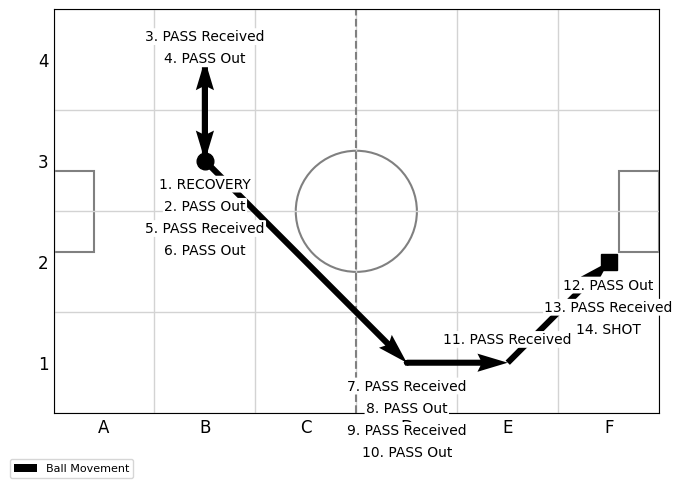

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import string
import matplotlib.cm as cm

# Convert grid cell name to center coordinates (A1 is bottom-left)
def cell_to_coords(cell):
    col_letter = cell[0].upper()
    row_number = int(cell[1:]) - 1
    col_number = string.ascii_uppercase.index(col_letter)
    return (col_number + 0.5, row_number + 0.5)


colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a','#b15928']

fig, ax = plt.subplots(figsize=(7, 7))

cols = 6  # A-F
rows = 4  # 1-4

# Draw grid lines
for i in range(cols + 1):
    ax.plot([i, i], [0, rows], color='lightgray', linewidth=1)
for j in range(rows + 1):
    ax.plot([0, cols], [j, j], color='lightgray', linewidth=1)

# Set axis limits
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)

# Set axis ticks to be at cell edges (so labels appear centered on cells)
ax.set_xticks(np.arange(cols) + 0.5)
ax.set_yticks(np.arange(rows) + 0.5)

# Set tick labels: x-axis letters A-F
ax.set_xticklabels(list(string.ascii_uppercase[:cols]), fontsize=12)
# y-axis numbers 1-4 (bottom to top)
ax.set_yticklabels([str(i) for i in range(1, rows + 1)], fontsize=12)

# Remove minor ticks and grid
ax.tick_params(axis='both', which='both', length=0)  # no tick marks

# Draw soccer field elements (unchanged)
ax.plot([3, 3], [0, rows], color='gray', linestyle='--', linewidth=1.5)
center_circle = plt.Circle((3, 2), 0.6, color='gray', fill=False, linewidth=1.5)
ax.add_patch(center_circle)
left_goal_area = plt.Rectangle((0, 1.6), 0.4, 0.8, edgecolor='gray', facecolor='none', linewidth=1.5)
ax.add_patch(left_goal_area)
right_goal_area = plt.Rectangle((5.6, 1.6), 0.4, 0.8, edgecolor='gray', facecolor='none', linewidth=1.5)
ax.add_patch(right_goal_area)

####################################
# Ball movement plotting part
ball_path = ball_movement_grid_cells
ball_coords = [cell_to_coords(cell) for cell in ball_path]
Xb, Yb = zip(*ball_coords)
Ub = np.diff(Xb)
Vb = np.diff(Yb)

Xb_start = Xb[:-1]
Yb_start = Yb[:-1]

ax.quiver(Xb_start, Yb_start, Ub, Vb, angles='xy', scale_units='xy', scale=1,
          color='black', width=0.01, label='Ball Movement', zorder=10)


offset_base = 0.3  # base vertical offset
label_spacing = 0.22  # vertical spacing between stacked labels

# Keep track of how many labels per (x,y) cell center
label_counts = {}

for i in range(len(ball_path)):
    start_x = Xb[i]
    start_y = Yb[i]
    
    label = ball_movement_activities[i]
    
    # Key for this position rounded to a grid center (avoid floating issues)
    key = (round(start_x, 3), round(start_y, 3))
    
    # Count how many labels already here
    count = label_counts.get(key, 0)
    label_counts[key] = count + 1
    
    # Calculate vertical offset based on count
    y_offset = offset_base + count * label_spacing
    y_offset_above =offset_base - count * label_spacing
    
    
    # move label above if i in a chosen set, otherwise below
    labels_above = {2, 3, 10}  # indices of labels you want above (change as needed)
    if i in labels_above:
        ax.text(start_x, start_y + y_offset_above, label, fontsize=10, color='black',
                ha='center', va='top',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1'), zorder=11)
    else:
        ax.text(start_x, start_y - y_offset, label, fontsize=10, color='black',
                ha='center', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1'), zorder=11)


ax.plot(Xb[0], Yb[0], 'o', color='black', markersize=12)   # Start marker
ax.plot(Xb[-1], Yb[-1], 's', color='black', markersize=12) # End marker
####################################


ax.set_aspect('equal')
ax.legend(loc='upper center', bbox_to_anchor=(0.03, -0.1), ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig("spatialView_withoutPlayers.png", dpi=300)
plt.show()


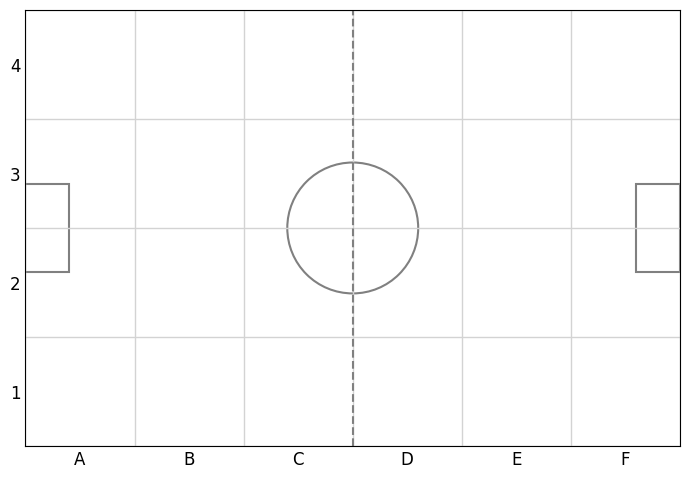

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import string
import matplotlib.cm as cm

# Convert grid cell name to center coordinates (A1 is bottom-left)
def cell_to_coords(cell):
    col_letter = cell[0].upper()
    row_number = int(cell[1:]) - 1
    col_number = string.ascii_uppercase.index(col_letter)
    return (col_number + 0.5, row_number + 0.5)


colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a','#b15928']

fig, ax = plt.subplots(figsize=(7, 7))

cols = 6  # A-F
rows = 4  # 1-4

# Draw grid lines
for i in range(cols + 1):
    ax.plot([i, i], [0, rows], color='lightgray', linewidth=1)
for j in range(rows + 1):
    ax.plot([0, cols], [j, j], color='lightgray', linewidth=1)

# Set axis limits
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)

# Set axis ticks to be at cell edges (so labels appear centered on cells)
ax.set_xticks(np.arange(cols) + 0.5)
ax.set_yticks(np.arange(rows) + 0.5)

# Set tick labels: x-axis letters A-F
ax.set_xticklabels(list(string.ascii_uppercase[:cols]), fontsize=12)
# y-axis numbers 1-4 (bottom to top)
ax.set_yticklabels([str(i) for i in range(1, rows + 1)], fontsize=12)

# Remove minor ticks and grid
ax.tick_params(axis='both', which='both', length=0)  # no tick marks

# Draw soccer field elements (unchanged)
ax.plot([3, 3], [0, rows], color='gray', linestyle='--', linewidth=1.5)
center_circle = plt.Circle((3, 2), 0.6, color='gray', fill=False, linewidth=1.5)
ax.add_patch(center_circle)
left_goal_area = plt.Rectangle((0, 1.6), 0.4, 0.8, edgecolor='gray', facecolor='none', linewidth=1.5)
ax.add_patch(left_goal_area)
right_goal_area = plt.Rectangle((5.6, 1.6), 0.4, 0.8, edgecolor='gray', facecolor='none', linewidth=1.5)
ax.add_patch(right_goal_area)

####################################


####################################


ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("spatialView_empty.png", dpi=300)
plt.show()
